In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, RocCurveDisplay,auc

from mice_utils import get_split_info

In [2]:
mice_df = pd.read_pickle('meta-data/Jax_mice_with_splits_df.pickle')
nfolds,nsplits = get_split_info(mice_df)
print(nsplits,nfolds)


5 2


In [3]:
# Parameters for the dictionary 
window_length = 256*2 # 2s
n_centroids = 200
centroid_len = 256
n_windows = 100000
n_windows = 40000
str_si = 'sv'

pool_str = ''


(45,)
(45,)
(45,)
(45,)
(45,)
(45,)
(45,)
(45,)
(45,)
(45,)


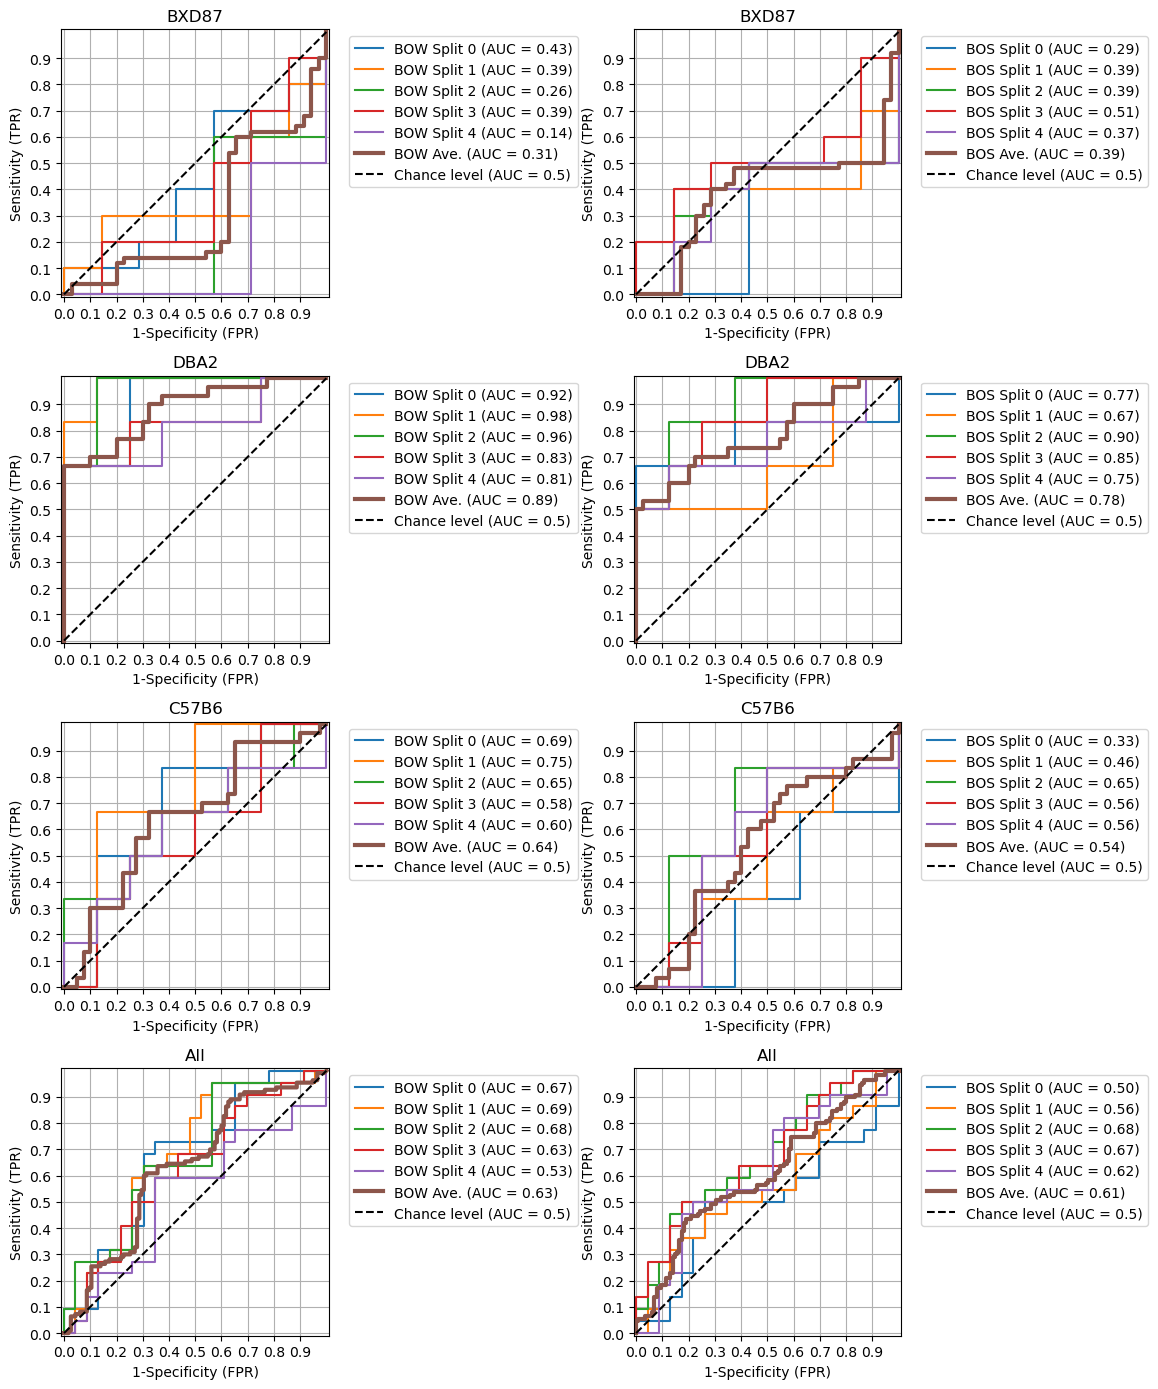

In [31]:
strains = ('BXD87', 'DBA2', 'C57B6')
all_strains = [s for s in strains] +['All']
nplot = 2
nstrains = len(strains)
n_seg = 480 # Number of segements per class 

#for use_spectral in [True,False]:
fig,axs = plt.subplots(ncols=nplot,nrows=nstrains+1,figsize=(12,14))
for j in range(nplot):
    if j ==0:
        use_spectral = False
        method= 'BOW'
    else:
        use_spectral = True
        method= 'BOS'

    if use_spectral:
        try:
            dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)
            run_name = pool_str+str(n_seg)+str(0)+dict_param_string
            v = np.load('./results/'+'tsc_given_bg'+run_name+'.npz')
        except:
            dict_param_string = 'spectral_'+str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_1'
            
    else:
        dict_param_string = str(n_windows)+'_'+str(window_length)+'_'+str(n_centroids)+'_'+str(centroid_len)+'_'+str_si

    all_tpr = {i:[] for i in range(nstrains+1) }

    mean_fpr = np.linspace(0, 1, 200)
    all_y_test = []
    all_y_prob = []

    for split in range(nsplits):
        run_name = pool_str+str(n_seg)+str(split)+dict_param_string
        v = np.load('./results/'+'tsc_given_bg'+run_name+'.npz')
        y_test_pooled = v['y_test_pooled']
        y_prob_pooled = v['y_prob_pooled']
        print(y_test_pooled.shape)
        all_y_test.append(y_test_pooled)
        all_y_prob.append(y_prob_pooled)
        
        for i in range(nstrains): 
            idx = (y_test_pooled//2) == i
            fpr, tpr, thresholds = roc_curve(y_test_pooled[idx]%2, y_prob_pooled[idx], pos_label=0)
            RocCurveDisplay(
                fpr=fpr, tpr=tpr, roc_auc=auc(fpr,tpr), estimator_name=method+ ' Split '+str(split)).plot(ax=axs[i,j])        
            all_tpr[i].append(np.interp(mean_fpr, fpr, tpr))
            
        
        fpr, tpr, thresholds = roc_curve(y_test_pooled%2, y_prob_pooled, pos_label=0)
        RocCurveDisplay(
            fpr=fpr, tpr=tpr, roc_auc=auc(fpr,tpr), estimator_name=method + ' Split '+str(split)).plot(ax=axs[nstrains,j])        
        axs[nstrains,j].set_ylabel('Sensitivity (TPR)')
        axs[nstrains,j].set_title('Given strain')
        axs[nstrains,j].set_xlabel('1-Specificity (FPR)')
        all_tpr[nstrains].append(np.interp(mean_fpr, fpr, tpr))

    for do_twice in [1]:#range(2):
        for i in range(nstrains+1): 
            if do_twice==0:  
                mean_tpr = np.mean(all_tpr[i],axis=0)
                mean_tpr[[0,-1]] = [0.0,1.0]
                ave_name = 'Vert. Ave.'
            else:
                y_test_pooled = np.concatenate(all_y_test)
                y_prob_pooled = np.concatenate(all_y_prob)
                if i<nstrains:
                    idx = (y_test_pooled//2) == i
                else:
                    idx = y_test_pooled>=0
                mean_fpr, mean_tpr, thresholds = roc_curve(y_test_pooled[idx]%2, y_prob_pooled[idx], pos_label=0)
                ave_name = method+' Ave.'
                
            roc_display = RocCurveDisplay(fpr=mean_fpr, tpr=mean_tpr, roc_auc=auc(mean_fpr,mean_tpr), estimator_name=ave_name).plot(ax=axs[i,j],lw=3,plot_chance_level=do_twice==1)        
            roc_display.ax_.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            roc_display.ax_.set_xticks(np.arange(0,1,.1))
            roc_display.ax_.set_yticks(np.arange(0,1,.1))
            axs[i,j].set_ylabel('Sensitivity (TPR)')
            axs[i,j].set_title(all_strains[i])
            axs[i,j].set_xlabel('1-Specificity (FPR)')
            axs[i,j].grid(visible=True, which='both')

plt.tight_layout()
plt.savefig('./figures/'+'ROC'+'.pdf', bbox_inches='tight')
